In [1]:
import os
import datetime
import pickle
import bz2

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt

# from tqdm.notebook import tqdm
import tqdm

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Geographiclib - https://geographiclib.sourceforge.io/Python/2.0/
# conda install conda-forge::geographiclib
from geographiclib.geodesic import Geodesic
geod = Geodesic.WGS84

In [2]:
plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']    = 'bold'
plt.rcParams['axes.titleweight']    = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['grid.linestyle'] = ':'

In [3]:
region_dct = {}
region_dct['World'] = tmp = {}
tmp['xlim'] = (-180, 180)
tmp['ylim'] = ( -90,  90)

# Continental US (CONUS)
region_dct['CONUS'] = tmp = {}
tmp['xlim'] = (-130,-56)
tmp['ylim'] = (  20, 55)

# CONUS + Canada
region_dct['CONUSCanada'] = tmp = {}
tmp['xlim'] = (-130, -56)
tmp['ylim'] = (  20,  80)

In [4]:
date   = datetime.datetime(2018,12,15)
frange = (14.000e6,14.350e6)

# Load Data

In [6]:
ham_dir   = 'ham_data'
ham_fname = '{!s}_{!s}-{!s}kHz_hamSpot.pkl.bz2'.format(
    date.strftime('%Y%m%d'),int(frange[0]/1e3),int(frange[1]/1e3))
ham_fpath = os.path.join(ham_dir,ham_fname)
print(ham_fpath)

ham_data/20181215_14000-14350kHz_hamSpot.pkl.bz2


In [7]:
# Load the compressed data from the file
with open(ham_fpath, "rb") as f:
    compressed_data = f.read()

# Decompress the data
pickled_data = bz2.decompress(compressed_data)

# Unpickle the data
df = pickle.loads(pickled_data)

del compressed_data
del pickled_data

In [8]:
df

,date,call_sign_tx,txlat,txlon,call_sign_rx,rxlat,rxlon,tfreq,sn,smode,ssrc,pthlen,latcen,loncen
7,2018-12-15 00:00:00,N8MDP,41.3958,-81.2083,KN3A,40.0625,-76.4583,14075455.0,-18.0,'FT8',PSK,426.8,40.7535,-78.8095
33,2018-12-15 00:00:00,W1JGM,41.4375,-73.5417,N6PAA,38.2313,-121.5792,14075301.0,-18.0,'FT8',PSK,4064.5,42.4027,-98.1565
38,2018-12-15 00:00:00,W0PE,33.8919,-117.7835,N7BT,48.8125,-122.5417,14075574.0,-20.0,'FT8',PSK,1705.1,41.3764,-119.8882
53,2018-12-15 00:00:00,RQ0C,48.5208,135.0417,JK1JAS,35.3542,139.5417,14074632.0,-9.0,'FT8',PSK,1509.9,41.9592,137.5251
54,2018-12-15 00:00:00,RQ0C,48.5208,135.0417,BG8FT,30.5625,103.5417,14074732.0,-16.0,'FT8',PSK,3320.4,40.6026,117.1847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10101657,2018-12-15 23:59:59,YB1RUS,-6.1875,106.7083,JE2UFF,34.8542,138.1250,14076053.0,-9.0,'FT8',PSK,5627.3,14.8601,120.8759
10101658,2018-12-15 23:59:59,YB1RUS,-6.1875,106.7083,JA1AZR,36.6458,140.7083,14076055.0,-4.0,'FT8',PSK,5931.9,15.8826,121.8385
10101693,2018-12-15 23:59:59,W2HTS,40.2999,-74.0707,W9HM,44.2813,-88.3792,14074407.0,-6.0,'FT8',PSK,1255.4,42.5133,-80.9975
10101775,2018-12-15 23:59:59,LU1XU,-54.8021,-68.3042,LU3XCC,-51.6354,-69.2292,14074983.0,-16.0,'FT8',PSK,357.5,-53.2196,-68.7838


# Unique TX and RX

In [10]:
# Unique Transmitters
tx_df = df[['call_sign_tx','txlat','txlon']].drop_duplicates('call_sign_tx').copy()

# Unique Receivers
rx_df = df[['call_sign_rx','rxlat','rxlon']].drop_duplicates('call_sign_rx').copy()

In [11]:
len(tx_df)

15328

# Maps

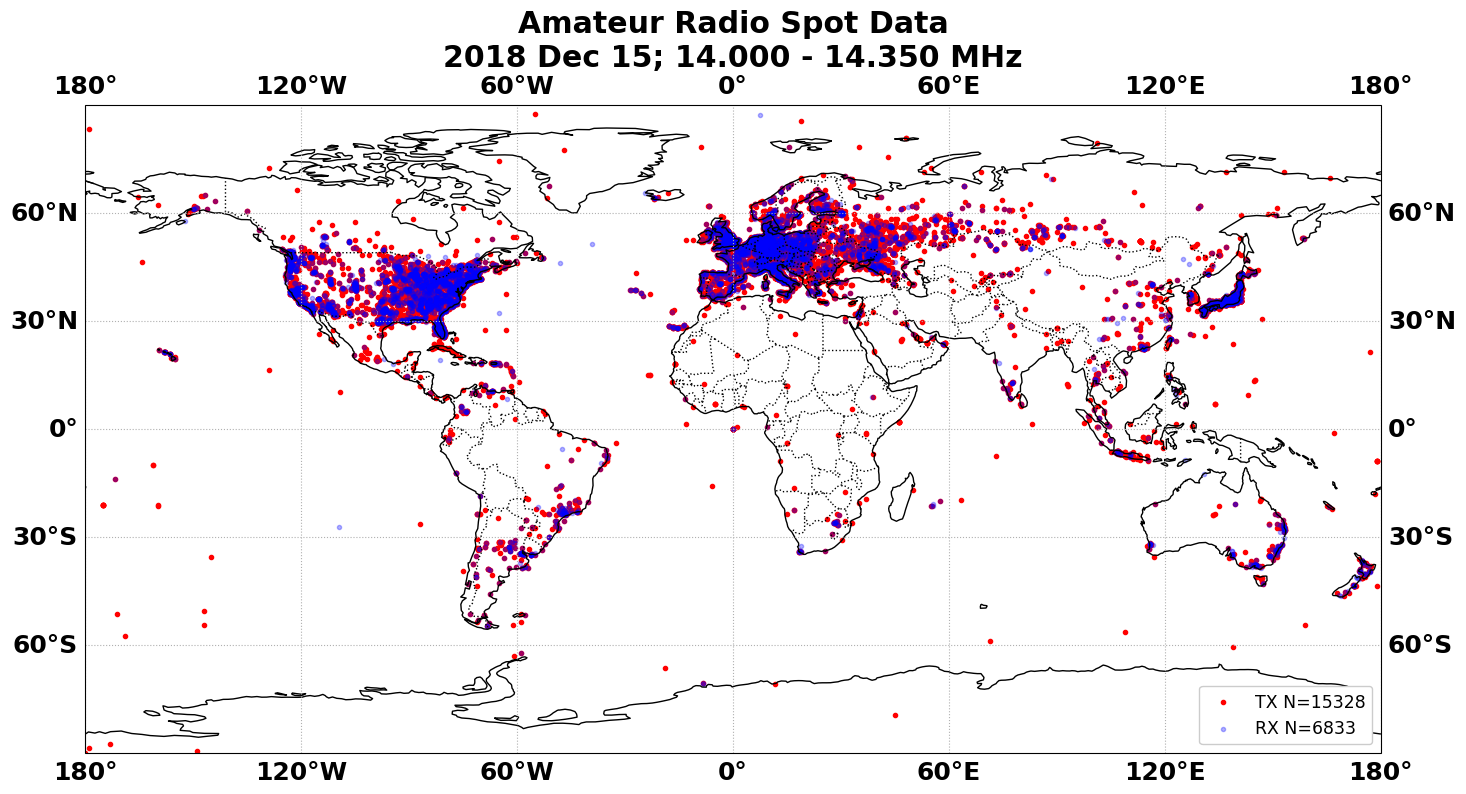

In [13]:
fig     = plt.figure(figsize=(15,8))
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

# Transmitters
xx = tx_df['txlon']
yy = tx_df['txlat']
ax.scatter(xx,yy,marker='.',color='r',label=f'TX N={len(xx)}')

# Receivers
xx = rx_df['rxlon']
yy = rx_df['rxlat']
ax.scatter(xx,yy,marker='.',color='b',alpha=0.3,label=f'RX N={len(xx)}')

ax.legend(loc='lower right',prop={'size':'x-small','weight':'normal'},framealpha=1)

region = 'World'
rdct = region_dct.get(region,region_dct['World'])
ax.set_xlim(rdct['xlim'])
ax.set_ylim(rdct['ylim'])

title = []
title.append('Amateur Radio Spot Data')
date_str = date.strftime('%Y %b %d')
f_str    = '{:0.3f} - {:0.3f} MHz'.format(frange[0]/1e6,frange[1]/1e6)
title.append(f'{date_str}; {f_str}')
ax.set_title('\n'.join(title))

plt.tight_layout()
plt.show()

In [14]:
paths = len(tx_df) * len(rx_df)
print(f'Theoretical TX-RX Paths: {paths:,}')
print()

hrs      = 12
dt_min   = 10
n_steps  = int((hrs*60) / dt_min)
n_traces = n_steps * paths
print('Simulation Calculator')
print(f'  Duration [hr]:  {hrs}')
print(f'  Cadence  [min]: {dt_min}')
print(f'  N Time Steps:   {n_steps}')
print(f'  N Traces:       {n_traces:,}')

Theoretical TX-RX Paths: 104,736,224

Simulation Calculator
  Duration [hr]:  12
  Cadence  [min]: 10
  N Time Steps:   72
  N Traces:       7,541,008,128


# TX-RX Combinatorics

In [16]:
# Make dataframe of all possible TX-RX paths.
tic = datetime.datetime.now()
df_paths = []
for rx_rinx, rx_row in tqdm.tqdm(rx_df.iterrows(),total=len(rx_df)):
    df_tmp = tx_df.copy()
    df_tmp.loc[:,'call_sign_rx'] = rx_row['call_sign_rx']
    df_tmp.loc[:,'rxlat']        = rx_row['rxlat']
    df_tmp.loc[:,'rxlon']        = rx_row['rxlon']
    df_paths.append(df_tmp)

df_paths = pd.concat(df_paths,ignore_index=True)
toc = datetime.datetime.now()
print(toc-tic)
print(len(df_paths))

100%|████████████████████████████████████████████████████████████████████████████████████████| 6833/6833 [00:01<00:00, 3435.79it/s]


0:00:03.349933
104736224


# Compute Midpoints, Ranges, and Azimuths

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of Earth in kilometers (use 3956 for miles)
    r = 6371
    return c * r

def midpoint(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Calculate midpoint
    Bx = np.cos(lat2) * np.cos(lon2 - lon1)
    By = np.cos(lat2) * np.sin(lon2 - lon1)
    lat_mid = np.arctan2(np.sin(lat1) + np.sin(lat2), np.sqrt((np.cos(lat1) + Bx) ** 2 + By ** 2))
    lon_mid = lon1 + np.arctan2(By, np.cos(lat1) + Bx)

    # Convert from radians to degrees
    lat_mid = np.degrees(lat_mid)
    lon_mid = np.degrees(lon_mid)
    
    # Convert longitudes from (0, 360) to (-180, 180)
    tf = lon_mid > 180
    lon_mid[tf] = lon_mid[tf]-360

    tf = lon_mid < -180
    lon_mid[tf] = lon_mid[tf]+360
    
    return lat_mid, lon_mid

def calc_azimuth(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    
    initial_bearing = np.arctan2(x, y)
    
    # Convert from radians to degrees and normalize to 0-360
    azimuth_deg = (np.degrees(initial_bearing) + 360) % 360
    return azimuth_deg

In [19]:
tic = datetime.datetime.now()

In [20]:
# distance = haversine(lat1, lon1, lat2, lon2)
df_paths['pthlen'] = haversine(df_paths['txlat'], df_paths['txlon'], df_paths['rxlat'], df_paths['rxlon'])

In [21]:
# mid_lat, mid_lon = midpoint(lat1, lon1, lat2, lon2)
df_paths['latcen'], df_paths['loncen'] = midpoint(df_paths['txlat'], df_paths['txlon'], df_paths['rxlat'], df_paths['rxlon'])

In [22]:
# azimuth = calc_azimuth(lat1, lon1, lat2, lon2)
df_paths['azm'] = calc_azimuth(df_paths['txlat'], df_paths['txlon'], df_paths['rxlat'], df_paths['rxlon'])

In [23]:
toc = datetime.datetime.now()
print(toc-tic)

0:00:19.901938


# Path Selection

In [25]:
# Make copy of dataframe with all paths.
df_paths_0 = df_paths.copy()

In [26]:
df_paths = df_paths_0.copy()

# Select only paths with great circle distances <= 3000 km.
max_path = 3000
tf = df_paths['pthlen'] <= max_path
df_paths = df_paths[tf]

# Select only paths with Continental US Midpoints
lon_0, lon_1    = (-130,-56)
lat_0, lat_1    = (20,55)  # CONUS

tf = np.logical_and(df_paths['loncen'] >= lon_0, df_paths['loncen'] < lon_1)
df_paths = df_paths[tf]

tf = np.logical_and(df_paths['latcen'] >= lat_0, df_paths['latcen'] < lat_1)
df_paths = df_paths[tf]

# Make sure selected df_paths is an independent object in memory.
df_paths = df_paths.copy()

# Reset index of selected paths.
df_paths.index = range(len(df_paths))

# Monte Carlo Selection

In [28]:
N_samples = 3000
rng       = np.random.default_rng()
randInxs  = rng.integers(0,len(df_paths),N_samples)
df_monte  = df_paths.iloc[randInxs]

# Midpoint Maps

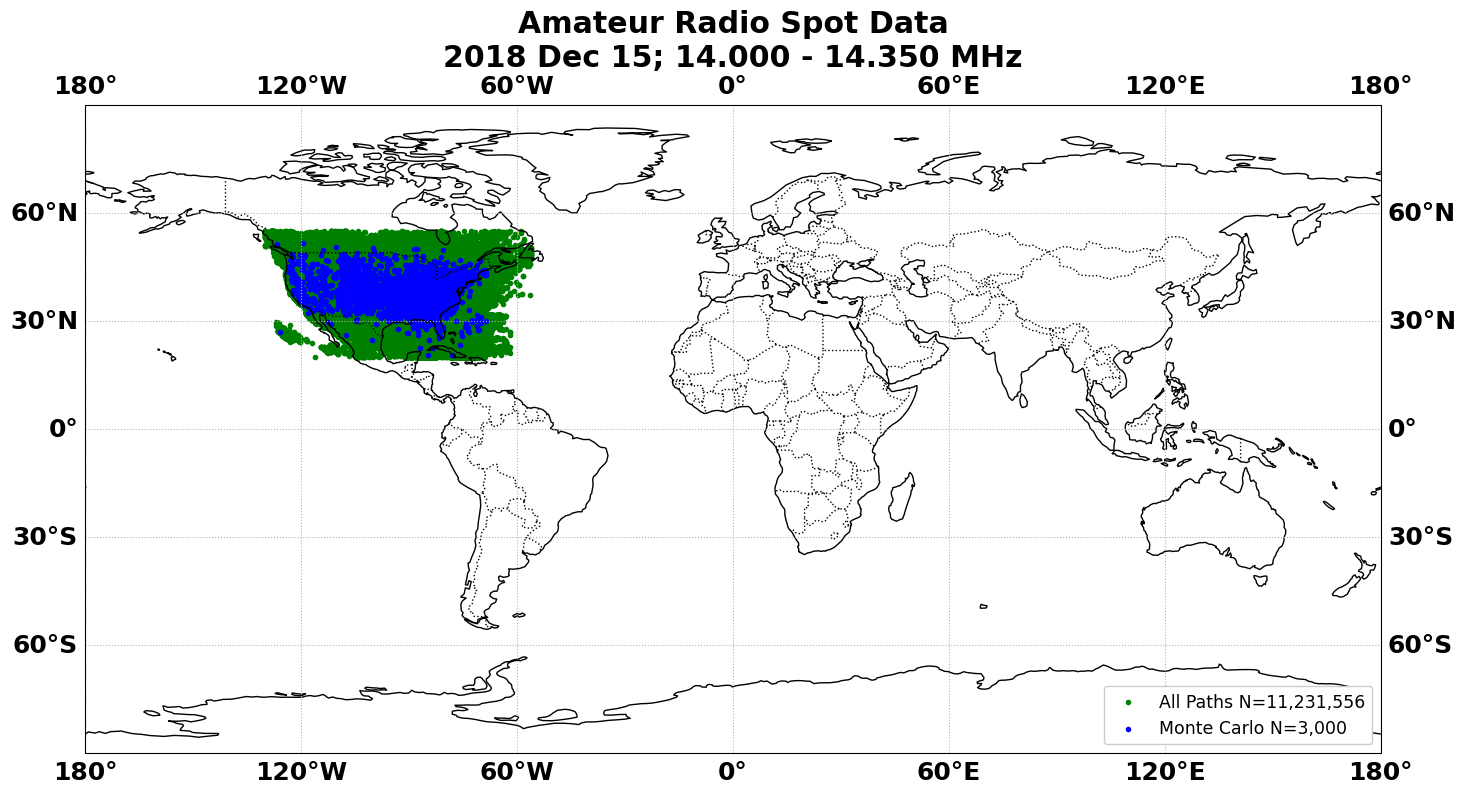

In [30]:
fig     = plt.figure(figsize=(15,8))
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

# Midpoints
xx = df_paths['loncen']
yy = df_paths['latcen']
ax.scatter(xx,yy,marker='.',color='g',label=f'All Paths N={len(xx):,}')

# Midpoints
xx = df_monte['loncen']
yy = df_monte['latcen']
ax.scatter(xx,yy,marker='.',color='b',label=f'Monte Carlo N={len(xx):,}')

ax.legend(loc='lower right',prop={'size':'x-small','weight':'normal'},framealpha=1)
    
region = 'World'
rdct = region_dct.get(region,region_dct['World'])
ax.set_xlim(rdct['xlim'])
ax.set_ylim(rdct['ylim'])

title = []
title.append('Amateur Radio Spot Data')
date_str = date.strftime('%Y %b %d')
f_str    = '{:0.3f} - {:0.3f} MHz'.format(frange[0]/1e6,frange[1]/1e6)
title.append(f'{date_str}; {f_str}')
ax.set_title('\n'.join(title))

plt.tight_layout()
plt.show()

# Midpoint Heatmaps

In [32]:
def plot_heatmap(df_paths, region='CONUS', label = ''):
    dlat = 1
    dlon = 1
    lat_bins = np.arange(-90,90+dlat,dlat)
    lon_bins = np.arange(-180,180+dlat,dlat)
    bins     = (lon_bins, lat_bins)
    
    xx = df_paths['loncen']
    yy = df_paths['latcen']
    heatmap, LON_BINS, LAT_BINS = np.histogram2d(xx,yy,bins=bins)
    
    fig     = plt.figure(figsize=(15,8))
    ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
    ax.set_title('')
    ax.gridlines(draw_labels=True)
    
    # Midpoints
    xx   = lon_bins
    yy   = lat_bins
    zz   = heatmap
    mpbl = ax.pcolormesh(xx,yy,zz.T)
    plt.colorbar(mpbl,label='N Midpoints',shrink=0.65,pad=0.075)
    
    txt  = f'{label} N = {len(df_paths):,}'
    ax.text(0.98,0.05,txt,transform=ax.transAxes,bbox={'facecolor':'white'},ha='right')

    rdct = region_dct.get(region,region_dct['World'])
    ax.set_xlim(rdct['xlim'])
    ax.set_ylim(rdct['ylim'])
    
    title = []
    title.append('Amateur Radio Spot Data')
    date_str = date.strftime('%Y %b %d')
    f_str    = '{:0.3f} - {:0.3f} MHz'.format(frange[0]/1e6,frange[1]/1e6)
    title.append(f'{date_str}; {f_str}')
    ax.set_title('\n'.join(title))
    
    plt.tight_layout()
    plt.show()

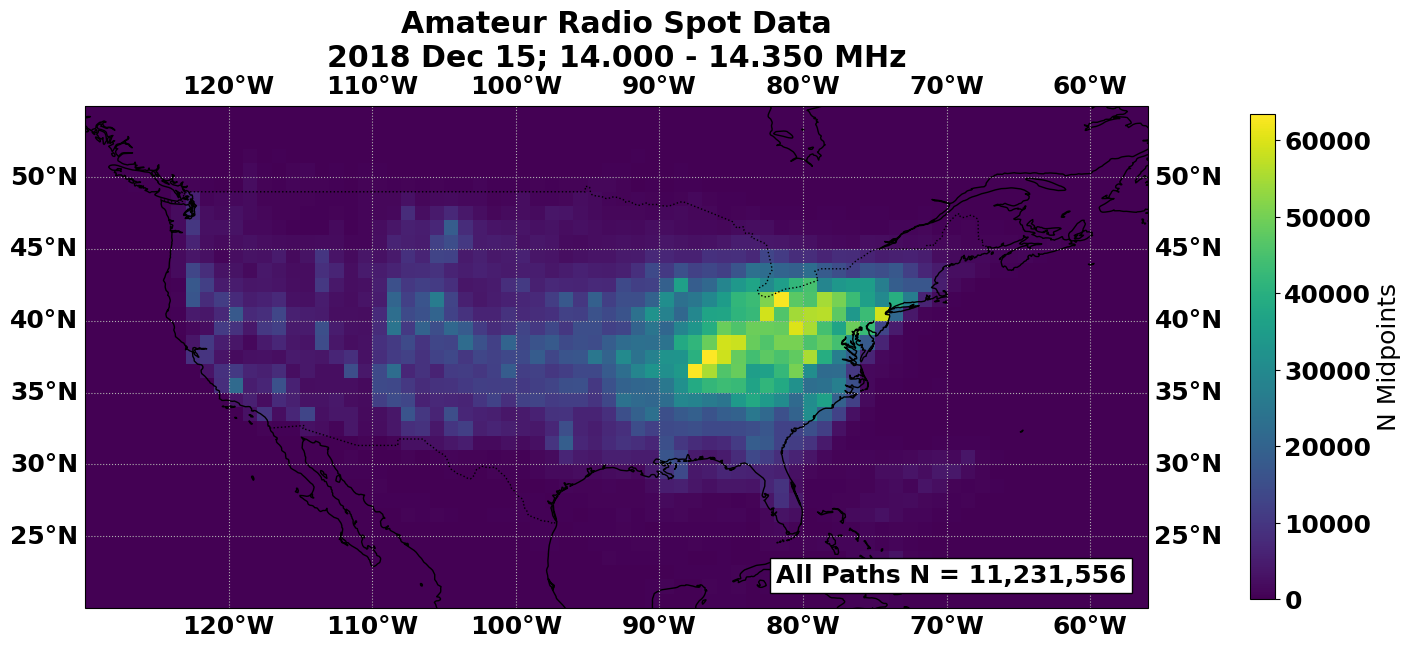

In [33]:
plot_heatmap(df_paths,label='All Paths')

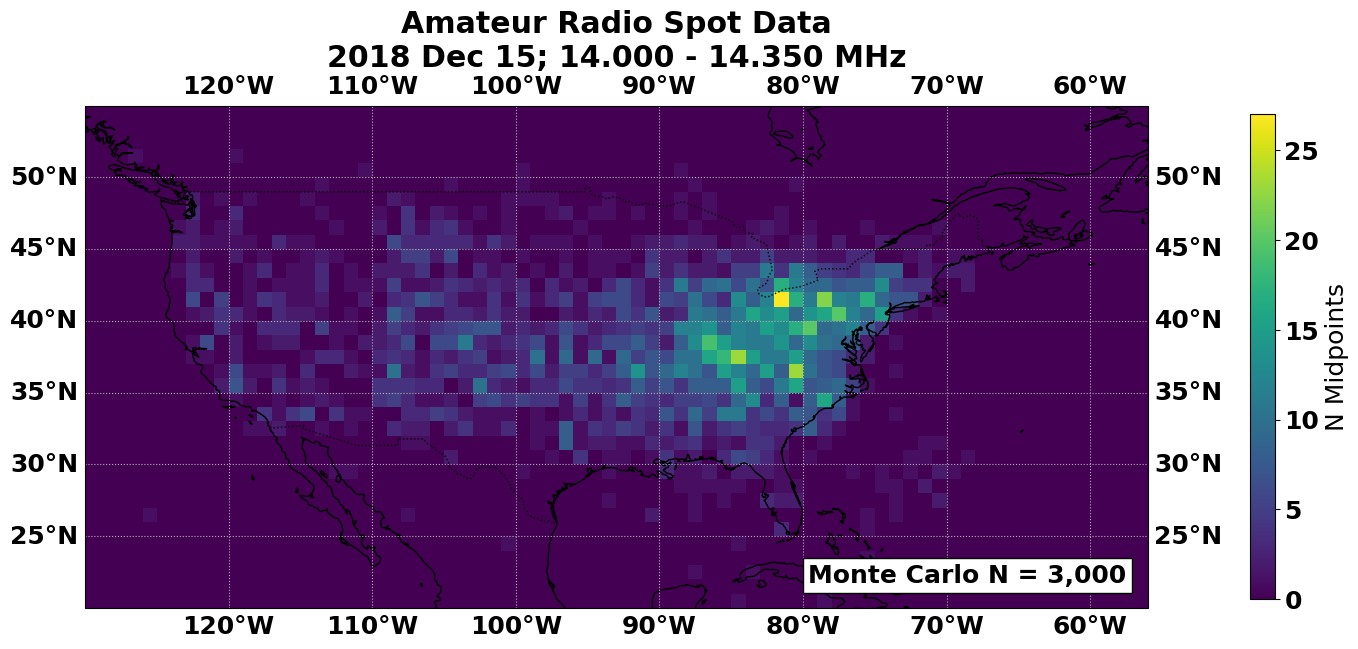

In [34]:
plot_heatmap(df_monte,label='Monte Carlo')

# Range and Azimuth Distrbutions

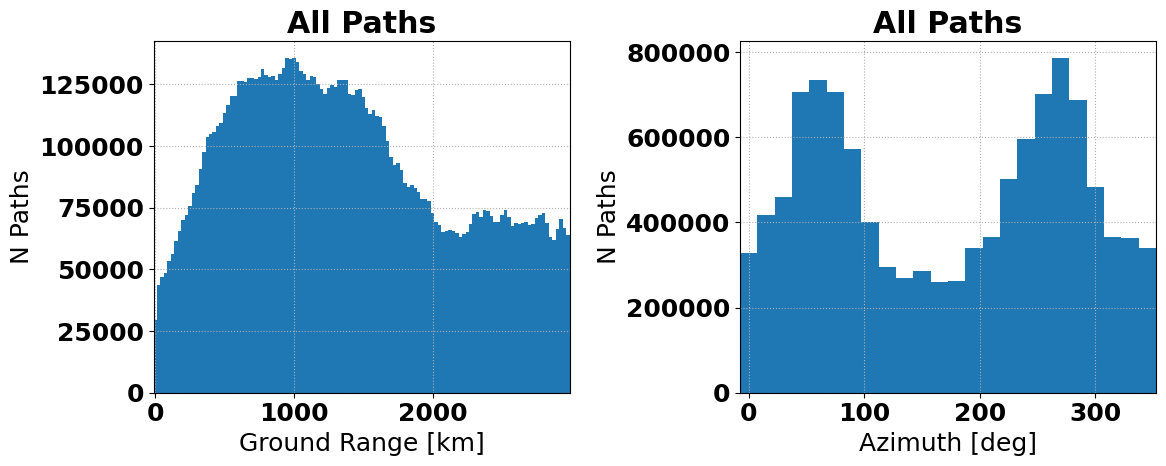

In [36]:
def plot_hists(df_paths,title=None):
    drange = 25
    bins   = np.arange(0,max_path+drange,drange)
    hist, range_bins = np.histogram(df_paths['pthlen'],bins=bins)
    
    dazm  = 15
    bins  = np.arange(0,360+dazm,dazm)
    azm_hist, azm_bins = np.histogram(df_paths['azm'],bins=bins)

    fig = plt.figure(figsize=(12,5))
    ax  = fig.add_subplot(1,2,1)
    plt.bar(range_bins[:-1],hist,width=drange)
    plt.xlabel('Ground Range [km]')
    plt.ylabel('N Paths')
    plt.title(title)
    
    ax  = fig.add_subplot(1,2,2)
    plt.bar(azm_bins[:-1],azm_hist,width=dazm)
    plt.xlabel('Azimuth [deg]')
    plt.ylabel('N Paths')
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_hists(df_paths,title='All Paths')

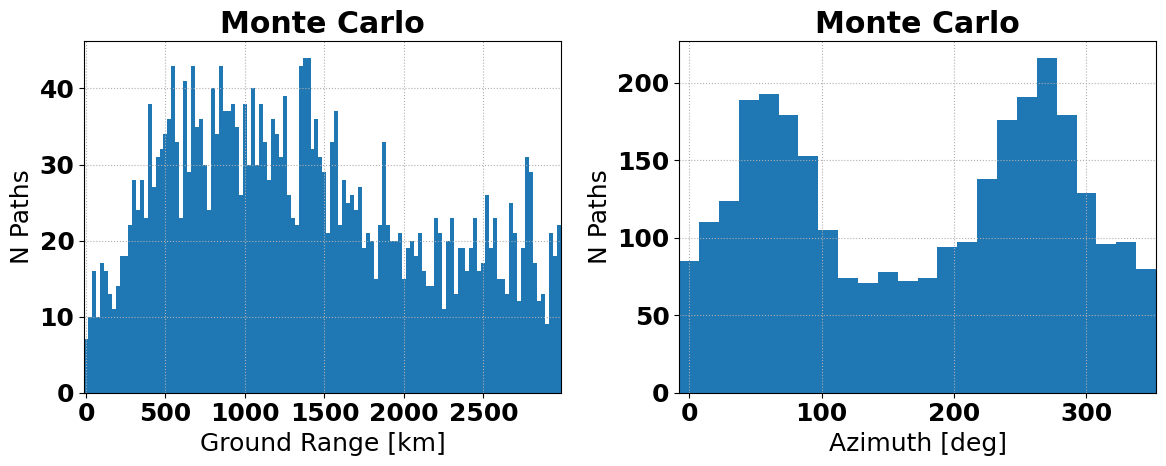

In [37]:
plot_hists(df_monte,title='Monte Carlo')